# 03 · Trend Analysis

How posting volume, sentiment, engagement, and topics move over time,
and how they break down by platform, region, and language.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/cleaned_social_media_sentiment.csv")
df["posted_datetime"] = pd.to_datetime(df["posted_datetime"])
df["engagement"] = df["like_count"] + df["share_count"] + df["comment_count"]

print(df["posted_datetime"].min(), "to", df["posted_datetime"].max())
df.columns.tolist()

2024-01-01 00:00:00 to 2025-12-01 00:00:00


['platform',
 'post_id',
 'user_id',
 'username',
 'user_verified',
 'user_followers_count',
 'user_location',
 'post_text',
 'language',
 'hashtags',
 'mentions',
 'post_length',
 'like_count',
 'comment_count',
 'share_count',
 'engagement_score',
 'posted_datetime',
 'day_of_week',
 'is_trending_topic',
 'topic_category',
 'sentiment_label',
 'sentiment_score',
 'emotion_label',
 'toxicity_score',
 'sarcasm_detected',
 'spam_flag',
 'data_source_url',
 'vader_compound',
 'vader_label',
 'engagement']

## Posting volume over time

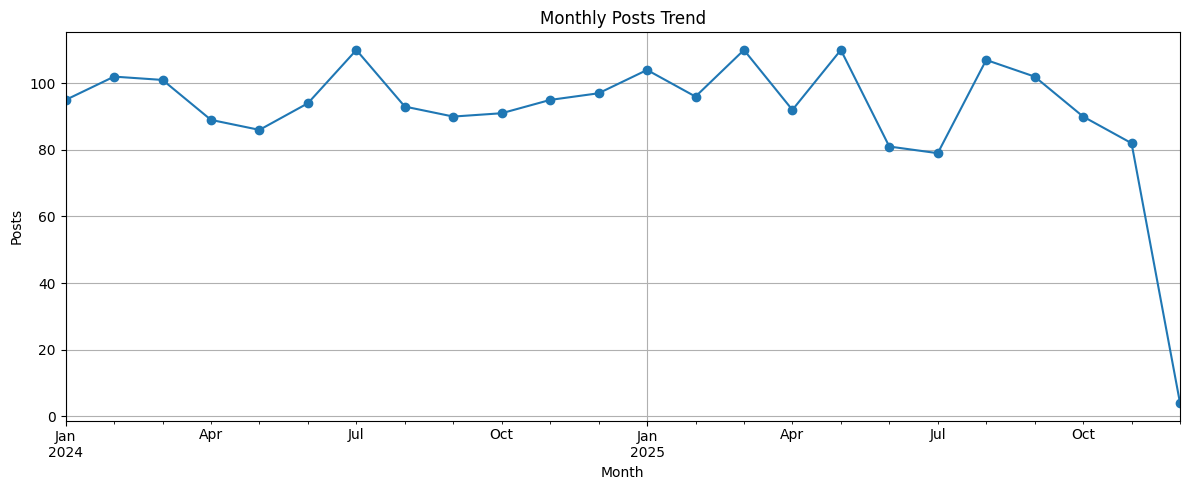

In [2]:
monthly_posts = df.groupby(df["posted_datetime"].dt.to_period("M")).size()

monthly_posts.plot(marker="o", figsize=(12, 5))
plt.title("Monthly Posts Trend")
plt.xlabel("Month")
plt.ylabel("Posts")
plt.grid(True)
plt.tight_layout()
plt.show()

## Sentiment over time

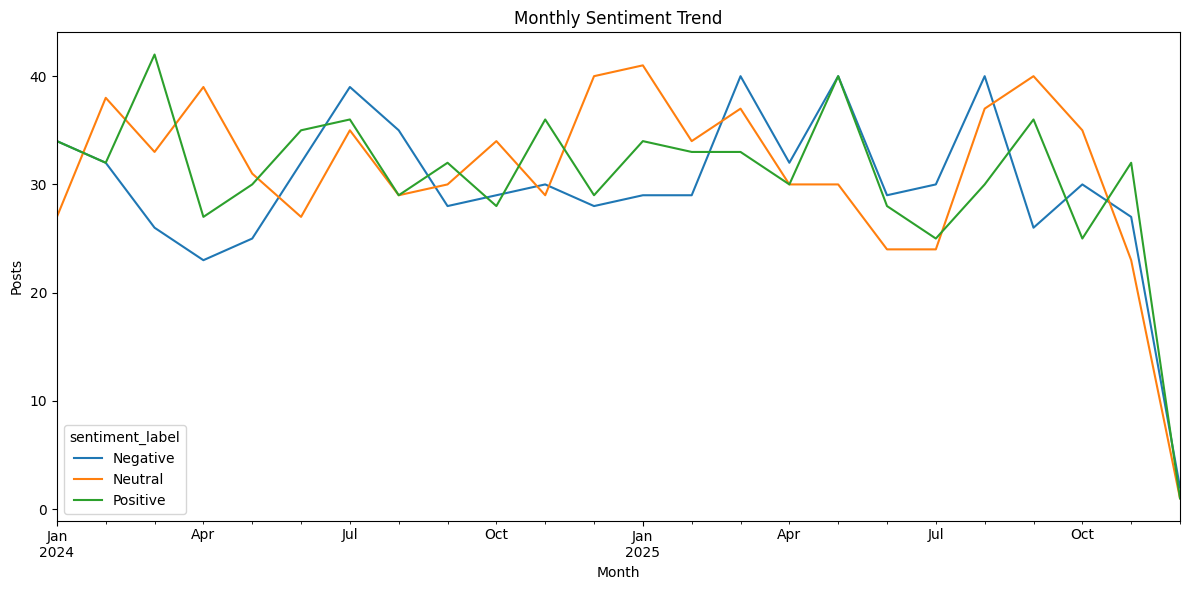

In [3]:
sentiment_trend = pd.crosstab(df["posted_datetime"].dt.to_period("M"), df["sentiment_label"])
sentiment_trend.plot(figsize=(12, 6))
plt.title("Monthly Sentiment Trend")
plt.xlabel("Month")
plt.ylabel("Posts")
plt.tight_layout()
plt.show()

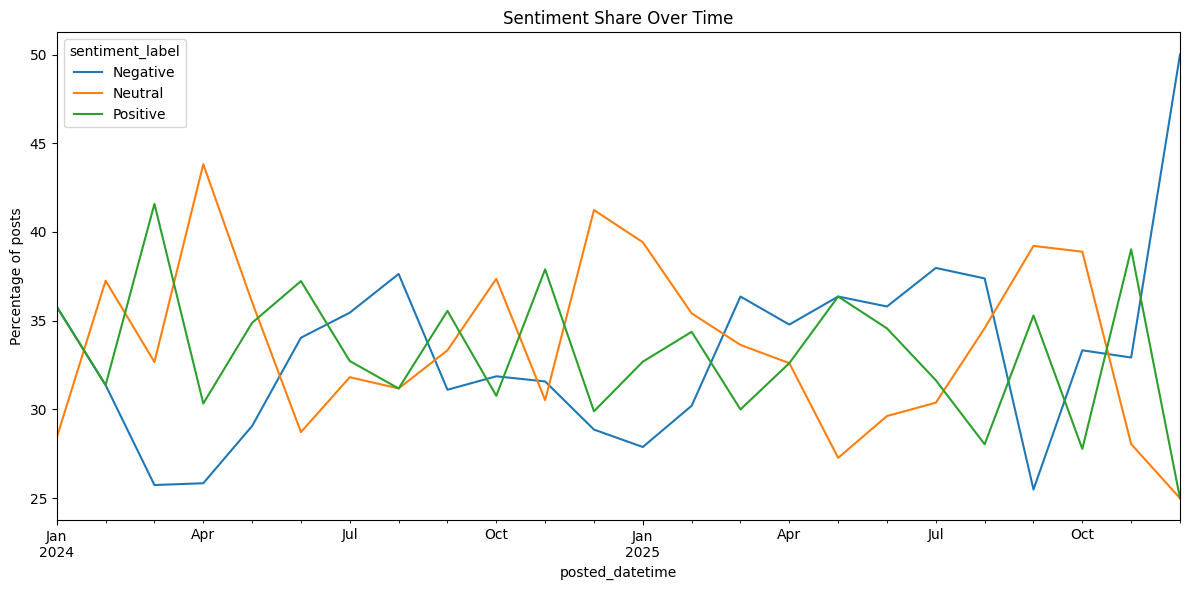

In [4]:
sentiment_percent = pd.crosstab(
    df["posted_datetime"].dt.to_period("M"), df["sentiment_label"], normalize="index"
) * 100

sentiment_percent.plot(figsize=(12, 6))
plt.title("Sentiment Share Over Time")
plt.ylabel("Percentage of posts")
plt.tight_layout()
plt.show()

## Platform trends

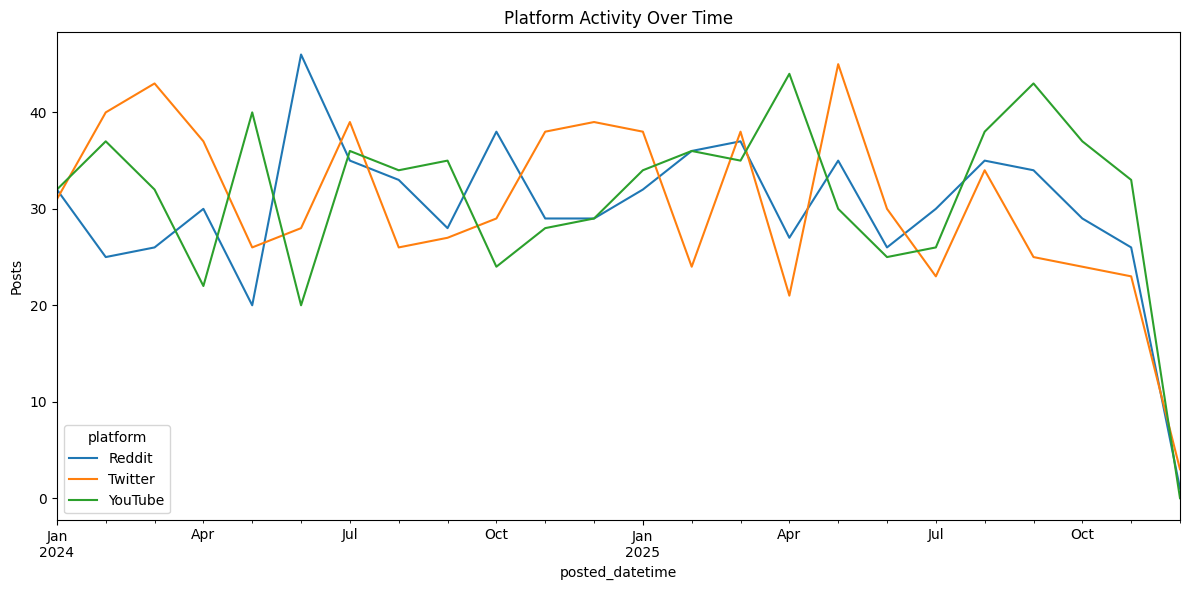

In [5]:
platform_trend = pd.crosstab(df["posted_datetime"].dt.to_period("M"), df["platform"])
platform_trend.plot(figsize=(12, 6))
plt.title("Platform Activity Over Time")
plt.ylabel("Posts")
plt.tight_layout()
plt.show()

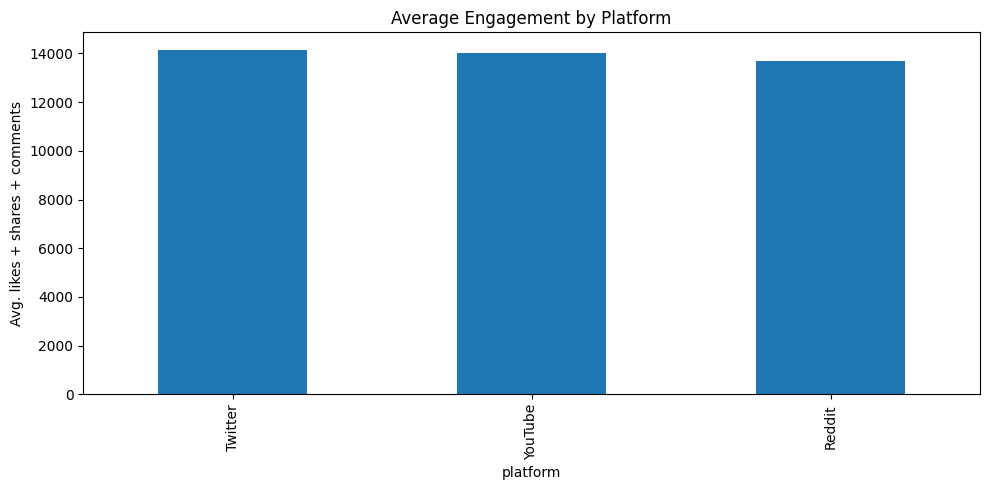

In [6]:
platform_engagement = df.groupby("platform")["engagement"].mean().sort_values(ascending=False)
platform_engagement.plot(kind="bar", figsize=(10, 5))
plt.title("Average Engagement by Platform")
plt.ylabel("Avg. likes + shares + comments")
plt.tight_layout()
plt.show()

## Topic trends

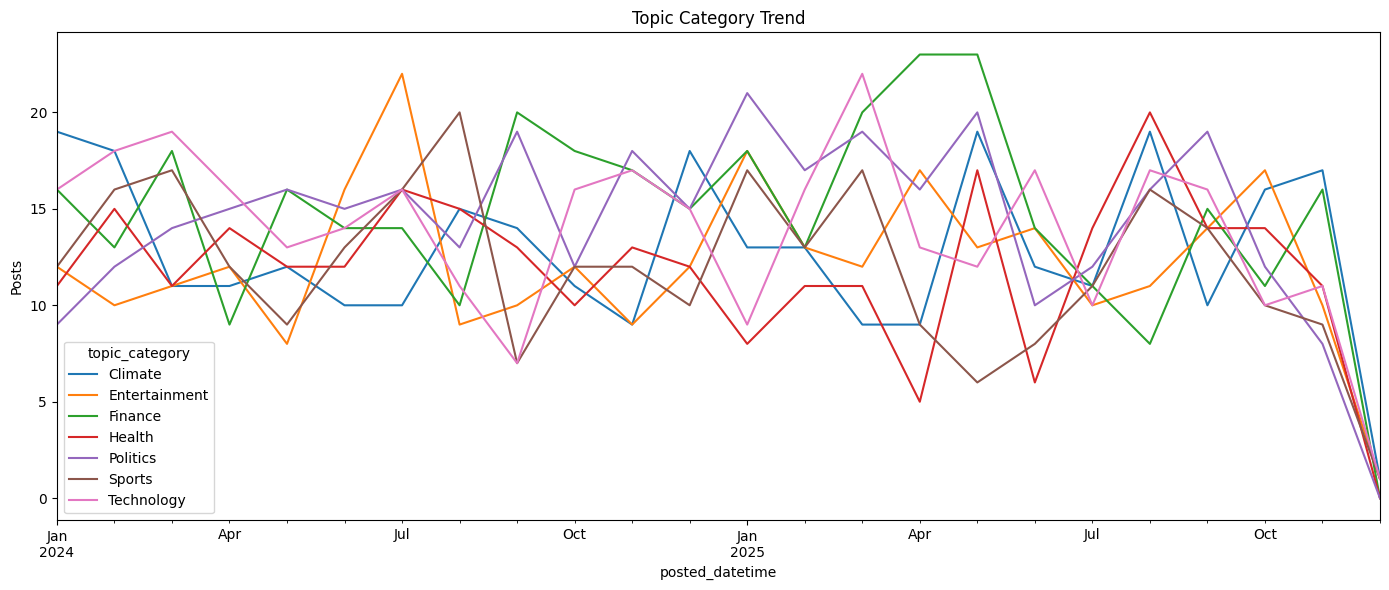

In [7]:
topic_trend = pd.crosstab(df["posted_datetime"].dt.to_period("M"), df["topic_category"])
topic_trend.plot(figsize=(14, 6))
plt.title("Topic Category Trend")
plt.ylabel("Posts")
plt.tight_layout()
plt.show()

## Region and language

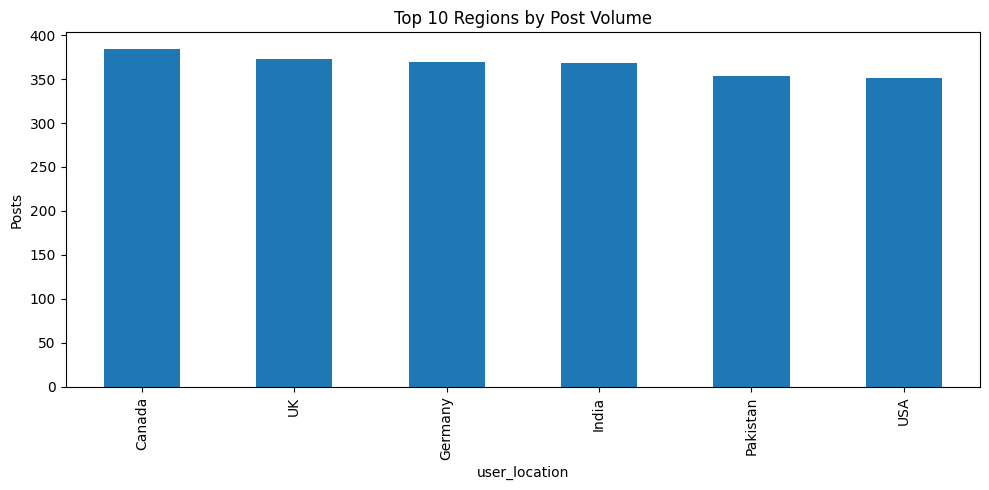

In [8]:
top_regions = df["user_location"].value_counts().head(10)
top_regions.plot(kind="bar", figsize=(10, 5))
plt.title("Top 10 Regions by Post Volume")
plt.ylabel("Posts")
plt.tight_layout()
plt.show()

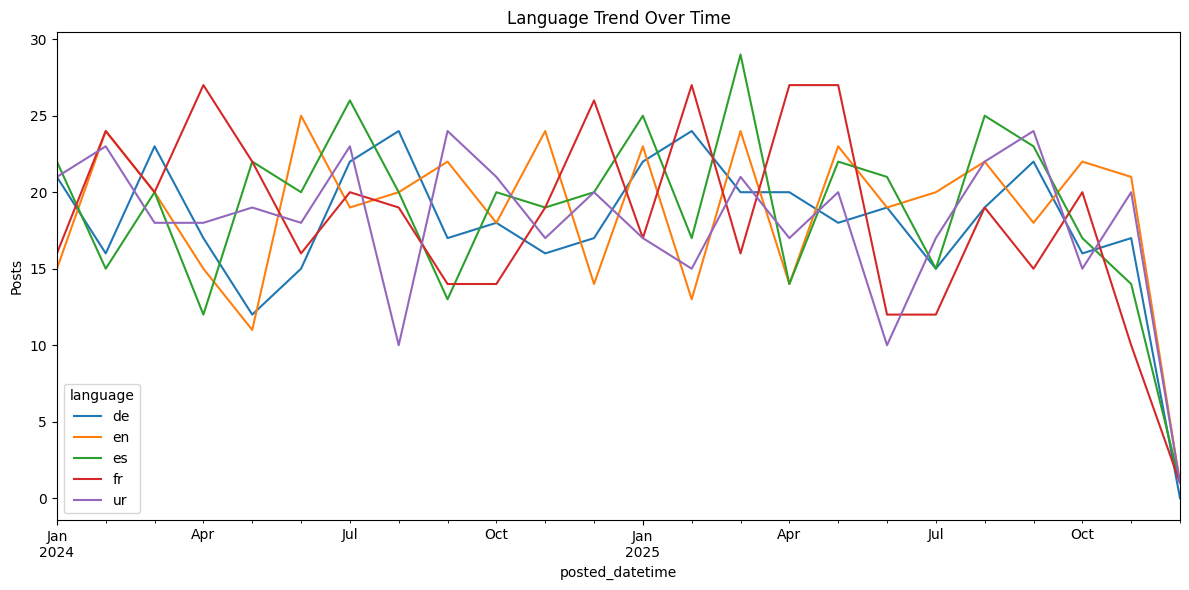

In [9]:
language_trend = pd.crosstab(df["posted_datetime"].dt.to_period("M"), df["language"])
language_trend.plot(figsize=(12, 6))
plt.title("Language Trend Over Time")
plt.ylabel("Posts")
plt.tight_layout()
plt.show()

## Verified vs unverified users

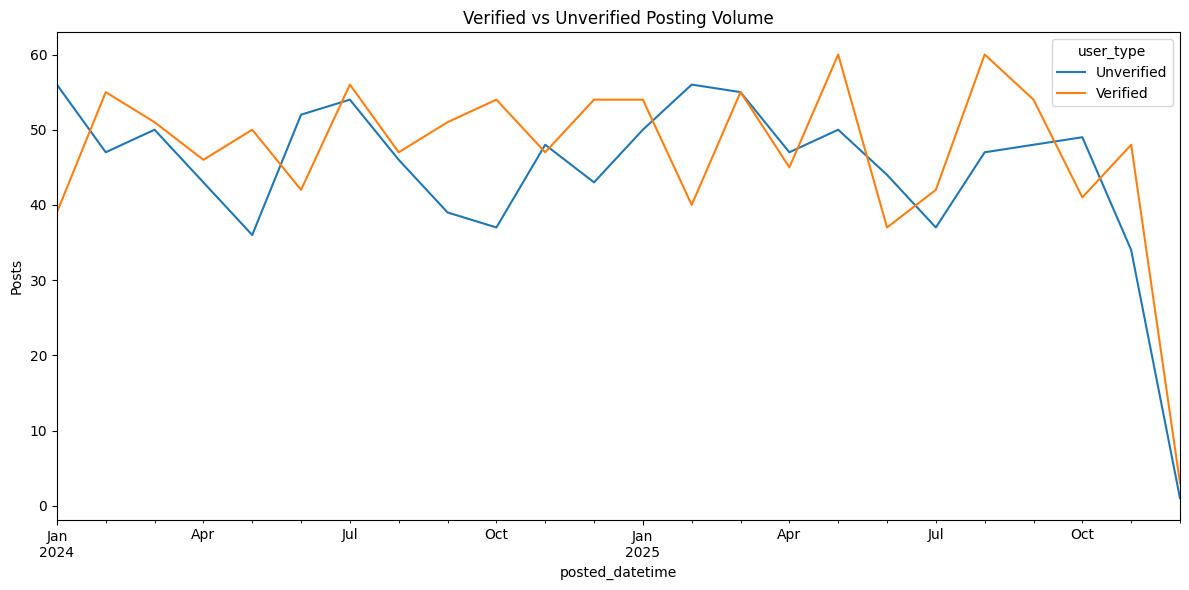

In [10]:
df["user_type"] = df["user_verified"].map({True: "Verified", False: "Unverified"})
user_trend = pd.crosstab(df["posted_datetime"].dt.to_period("M"), df["user_type"])
user_trend.plot(figsize=(12, 6))
plt.title("Verified vs Unverified Posting Volume")
plt.ylabel("Posts")
plt.tight_layout()
plt.show()

## Engagement over time

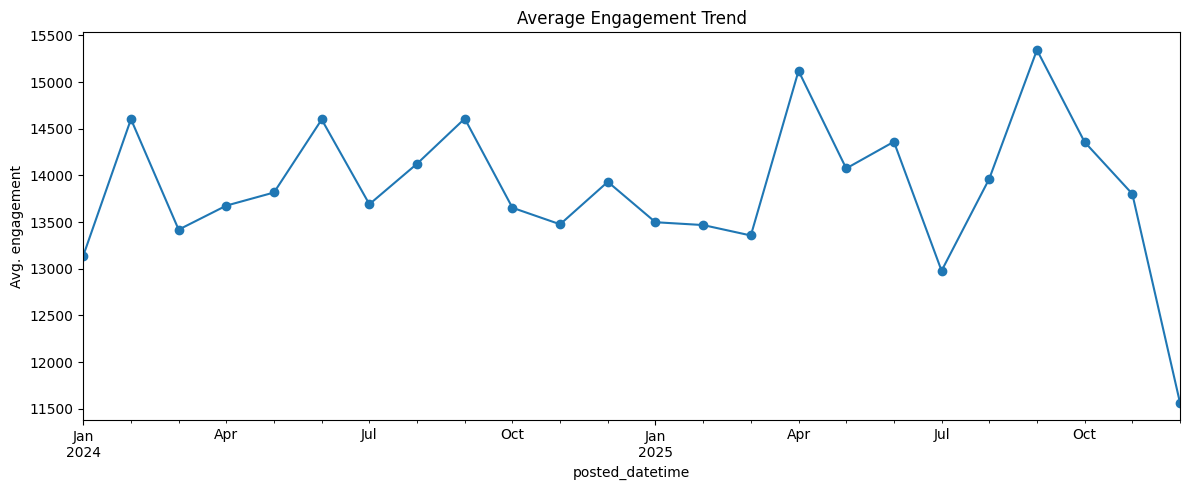

In [11]:
engagement_trend = df.groupby(df["posted_datetime"].dt.to_period("M"))["engagement"].mean()
engagement_trend.plot(marker="o", figsize=(12, 5))
plt.title("Average Engagement Trend")
plt.ylabel("Avg. engagement")
plt.tight_layout()
plt.show()